In [72]:
_catalog = 'AE'
_catalog = "Bielszowice_2022_2023"
_catalog = "Bielszowice.Katalog.SOS sc 314"
_catalog = "Bielszowice.Katalog.SOS sc 514"
_catalog = "Catalog_jaguars_aftershocks_fault"
_catalog = "Catalog_jaguars_aftershocks_full_verified"
_catalog = 'Catalog_jaguars_aftershocks_stope'
_catalog = 'Catalog_jaguars_blast_2007_12_15to16'
_catalog = 'Catalog_jaguars_blast_2008_04_30to05_01'
_catalog = 'Catalog_jaguars_blast_2008_05_10to11'
_catalog = 'Catalog_jaguars_scaling'
_catalog = 'Cooper_Basin_Catalog_HAB_1_2003_Reprocessed'
_catalog = 'Cooper_Basin_Catalog_HAB_1_2005'
_catalog = 'Cooper_Basin_Catalog_HAB_4'
_catalog = 'COTTON_VALLEY_Catalog'
_catalog = 'CZORSZTYN_catalog'
_catalog = 'CZORSZTYN_relocation_TRMLOC_catalog'
_catalog = 'Gazli_Catalog_3L'
_catalog = 'Gazli_Catalog_10L'
_catalog = 'Gazli_Catalog_Local'
_catalog = 'GISOS_catalog'
_catalog = 'Lacq_Catalog_1L'
_catalog = 'Lacq_Catalog_3L'
_catalog = 'Lacq_Catalog_10L'
_catalog = 'Lacq_Catalog_Local'
_catalog = 'LaiChau_local'
_catalog = 'Monteynard_Catalog_3L'
_catalog = 'Monteynard_Catalog_10L'
_catalog = 'Ruda_004_catalog'
_catalog = 'Ruda_005_catalog'
_catalog = 'Ruda_252_catalog'
_catalog = 'Ruda_310_catalog'
_catalog = 'Ruda_502a_catalog'
_catalog = 'Ruda_506a_catalog'
_catalog = 'Ruda_829_catalog'
_catalog = 'USCB_catalog'
_catalog = 'USCB_Ziemowit_catalog'

In [ ]:
_catalog = "USCB_Ziemowit_MTR-0.5"
_catalog = "USCB_Ziemowit_MTR-1"

Plots created in plotly to help estblish corect time 

Uzyty algorytm z automatycznego wyznaczania w celu latwiejszego dostrzeżenia faz


In [1]:
import os
import pandas as pd
from scipy.signal import find_peaks

import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio

# Wymuszenie otwarcia wykresu w przeglądarce internetowej 
pio.renderers.default = 'browser'

_catalog = 'USCB_Ziemowit_MTR-1.5'

core_name = f'{_catalog}_100ev.txt'
clean_name = os.path.splitext(core_name)[0]

csv_file_path = f"szukanie_faz/dane_{clean_name}.csv"
df = pd.read_csv(csv_file_path)

# bez nan
df = df.dropna(subset=("DC", "Log10_SSD"))

# Konwersja na datetime 
df['Datetime'] = pd.to_datetime(df['Datetime'])
#df['Datetime'] = pd.to_datetime(df['Datetime'], format='mixed')

## szukanie maksimum lokalnych SSD i jednocześnie minimów lokalnych DC w tym okresie czasu
peaks_ssd, _ = find_peaks(df['Log10_SSD'], distance=50, prominence=0.3)

print("Indeksy z pikami", peaks_ssd)
results = []

# szukanie w tym czasie minimum DC 
window_size = 100  # ile punktów wokół max SSD
mag_threshold = df['Mag'].quantile(0.90)

for p_ssd in peaks_ssd:
    # okno czasowe dla DC
    start = max(0, p_ssd - window_size)
    end = min(len(df) - 1, p_ssd + window_size)
    
    dc_window = df['DC'].iloc[start:end]
    p_dc = dc_window.idxmin()
    
    mag_window = df['Mag'].iloc[start:end]
    p_mag = mag_window.idxmax() 
    max_mag_val = mag_window.max()
    
    # jezeli w tym oknie jest magnituda wieksza?
    if max_mag_val >= mag_threshold:
        results.append({
            'SSD_Peak_Time': df['Datetime'].iloc[p_ssd],
            'Mainshock_Time': df['Datetime'].iloc[p_mag], 
            'DC_Min_Time': df['Datetime'].iloc[p_dc],
            'SSD_Peak_Val': df['Log10_SSD'].iloc[p_ssd],
            'Max_Mag_Val': max_mag_val,
            'DC_Min_Val': dc_window.min(),
            'SSD_idx': p_ssd,
            'DC_idx': p_dc,
            'Mag_idx': p_mag
        })

phase_ends = pd.DataFrame(results)

# ==============================================================================
#                               TWORZENIE WYKRESU PLOTLY
# ==============================================================================

fig = make_subplots(
    rows=3, cols=1, 
    shared_xaxes=True, 
    vertical_spacing=0.05,
    subplot_titles=("log10(SSD)", "DC", f"Wstrząsy (Mainshock M > {mag_threshold:.2f})")
)

# 1. Wykres Log10_SSD
fig.add_trace(
    go.Scatter(x=df['Datetime'], y=df['Log10_SSD'], mode='lines', name='Log10(SSD)', line=dict(color='red', width=1.5), opacity=0.7),
    row=1, col=1
)

# 2. Wykres DC
fig.add_trace(
    go.Scatter(x=df['Datetime'], y=df['DC'], mode='lines', name='DC', line=dict(color='green', width=1.5), opacity=0.7),
    row=2, col=1
)

# 3. Wykres Mag
fig.add_trace(
    go.Scatter(x=df['Datetime'], y=df['Mag'], mode='markers', name='Wstrząsy', marker=dict(color='black', size=4), opacity=0.5),
    row=3, col=1
)

# Nakładanie linii pionowych i gwiazdek 
for i, row in phase_ends.iterrows():
    t_ssd = row['SSD_Peak_Time']
    t_dc  = row['DC_Min_Time']
    t_mag = row['Mainshock_Time']
    
    # Linie pionowe dla wszystkich trzech podwykresów
    for r in [1, 2, 3]:
        # Czerwona przerywana linia dla SSD Peak
        fig.add_vline(x=t_ssd, line=dict(color="red", width=1, dash="dash"), opacity=0.4, row=r, col=1)
        # Niebieska kropkowana linia dla DC Min
        fig.add_vline(x=t_dc, line=dict(color="blue", width=1.2, dash="dot"), opacity=0.6, row=r, col=1)
    
    # Czarna ciągła linia dla Mainshock 
    fig.add_vline(x=t_mag, line=dict(color="black", width=1.5), opacity=0.8, row=3, col=1)
    
    # Złota gwiazdka dla głównego wstrząsu 
    fig.add_trace(
        go.Scatter(
            x=[t_mag], y=[row['Max_Mag_Val']], 
            mode='markers', 
            marker=dict(color='gold', size=12, symbol='star', line=dict(color='black', width=1)),
            showlegend=False
        ),
        row=3, col=1
    )

# ==============================================================================
#            KONFIGURACJA WYGLĄDU I WYŚWIETLANIA CZASU CO DO SEKUNDY
# ==============================================================================

# Konfiguracja etykiet po najechaniu myszką- format daty z sekundami
fig.update_traces(
    hovertemplate="<b>Czas:</b> %{x|%Y-%m-%d %H:%M:%S}<br><b>Wartość:</b> %{y:<.4f}<extra></extra>"
)

fig.update_layout(
    title=dict(
        text="Detekcja faz: Czerwona(SSD peak), Niebieska(DC min), Gwiazdka(Mainshock)",
        x=0.5
    ),
    height=900,  
    width=1200,  
    showlegend=True,
    template="plotly_white",  
    hovermode="x unified"    
)

fig.update_xaxes(
    tickformatstops=[
        dict(dtickrange=[None, 1000], value="%H:%M:%S.%L"),  
        dict(dtickrange=[1000, 60000], value="%H:%M:%S"),    
        dict(dtickrange=[60000, 3600000], value="%H:%M"),    
        dict(dtickrange=[3600000, 86400000], value="%H:%M"),  
        dict(dtickrange=[86400000, None], value="%Y-%m-%d")   # Widok ogólny (rok-miesiąc-dzień)
    ],
    gridcolor="lightgray",
    gridwidth=0.5
)

fig.update_yaxes(title_text="log10(SSD)", row=1, col=1)
fig.update_yaxes(title_text="DC", row=2, col=1)
fig.update_yaxes(title_text="Mag", row=3, col=1)
fig.update_xaxes(title_text="Czas", row=3, col=1)

fig.show()

Indeksy z pikami [222 455 977]


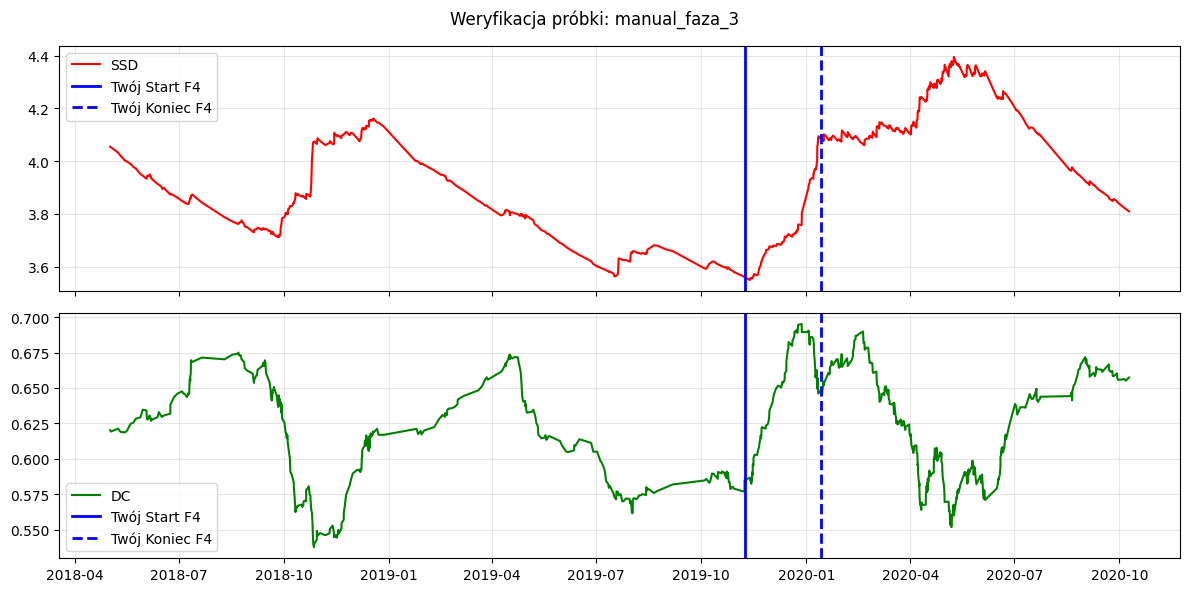

 Sukces! Zapisano plik: wyciete_fazy_manualnie_ziemowit_1.5/USCB_Ziemowit_MTR-1.5_100ev_manual_faza_3.csv


In [4]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# ==============================================================================
#       Daty kiedy zaczela sie faza oraz jakie okno zapisac 
# ==============================================================================
CZAS_START_WYCINKA  = '2018-05-01-10:00'
CZAS_KONIEC_WYCINKA = '2020-10-10-02:00'

FAZA_4_START        = '2019-11-08-04:00'
FAZA_4_KONIEC       = '2020-01-14-01:00'

NAZWA_PROBKI        = "manual_faza_3" # pamietaj zeby zmienic bo nadpisze sie plik
# ==============================================================================

#  FILTROWANIE I ETYKIETOWANIE
maska_wycinka = (df['Datetime'] >= CZAS_START_WYCINKA) & (df['Datetime'] <= CZAS_KONIEC_WYCINKA)
df_fragment = df[maska_wycinka].copy()

df_fragment['Label_Phase4'] = 0
maska_fazy = (df_fragment['Datetime'] >= FAZA_4_START) & (df_fragment['Datetime'] <= FAZA_4_KONIEC)
df_fragment.loc[maska_fazy, 'Label_Phase4'] = 1

# 3. WERYFIKACJA 
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
ax1.plot(df_fragment['Datetime'], df_fragment['Log10_SSD'], color='red', label='SSD')
ax2.plot(df_fragment['Datetime'], df_fragment['DC'], color='green', label='DC')

for ax in [ax1, ax2]:
    ax.axvline(x=pd.to_datetime(FAZA_4_START), color='blue', linestyle='-', linewidth=2, label='Twój Start F4')
    ax.axvline(x=pd.to_datetime(FAZA_4_KONIEC), color='blue', linestyle='--', linewidth=2, label='Twój Koniec F4')
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.suptitle(f"Weryfikacja próbki: {NAZWA_PROBKI}")
plt.tight_layout()
plt.show()

# 4. ZAPIS
output_dir = "wyciete_fazy_manualnie_ziemowit_1.5"
os.makedirs(output_dir, exist_ok=True)
df_fragment.to_csv(f"{output_dir}/{clean_name}_{NAZWA_PROBKI}.csv", index=False)
print(f" Sukces! Zapisano plik: {output_dir}/{clean_name}_{NAZWA_PROBKI}.csv")